# 08-Change Data Capture (CDC) with Debezium

In Lesson 06, we engineered an Incremental Data Loading pipeline using High-Water Marks ($H_t$). This allowed us to extract data deltas ($\Delta S_t$) dynamically, mitigating the massive I/O costs of full-table scans.

However, as database write-volumes scale to thousands of transactions per second, high-water marking exposes severe architectural limits:

1. **The Query Performance Penalty**: Querying a live production database with `SELECT ... WHERE updated_at > H_t` requires index scans that steal CPU cycles from active application users.
2. **The Hard Deletion Blindspot**: If an application user deletes a row (`DELETE FROM users WHERE id = 42`), that row completely vanishes from the table. Because it is gone, it has no `updated_at` value. High-water mark queries will completely miss this event, leaving stale, ghostly data inside your downstream analytics warehouse.

To achieve real-time synchronization with zero query overhead, we must move out of the database application layer and sink into the systems storage layer using **Change Data Capture (CDC)**. The global enterprise standard for this is **Debezium**.

Let's configure our environment to simulate raw log-based stream ingestion.

In [1]:
# Required installations: pip install duckdb pandas matplotlib seaborn
import duckdb
import pandas as pd
import json
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & CDC Log Engine Initialized.")

✅ Systems Architecture & CDC Log Engine Initialized.


# 1. The Mathematics of Write-Ahead Logs (WAL)

An application database does not write directly to data tables on disk; that is too slow. Instead, it appends every single mutating transaction (`INSERT`, `UPDATE`, `DELETE`) to an append-only binary file known as the **Write-Ahead Log (WAL)** in PostgreSQL or the **Binlog** in MySQL.

Let the database state at any microsecond be an accumulated ledger of row mutations:


$$\mathcal{L} = \{e_1, e_2, e_3, \dots, e_t\}$$


Where $e_i$ is a tuple representing a physical state change: $e_i = (\text{timestamp}, \text{op}, \text{before}, \text{after})$.

Debezium runs as a lightweight background daemon that hooks directly into the database storage engine. It reads the raw binary byte-stream of the WAL file directly from the filesystem. **It never executes a single SQL query against the tables.** When a transaction commits, Debezium instantly serializes the change event into a strict JSON payload containing both the pre-mutation state ($\text{before}$) and post-mutation state ($\text{after}$):

$$\text{Debezium}(e_i) = \begin{cases} 
\text{op}: \text{'c'}, \text{ before}: \emptyset, \text{ after}: X & \text{for INSERT} \\
\text{op}: \text{'u'}, \text{ before}: X, \text{ after}: Y & \text{for UPDATE} \\
\text{op}: \text{'d'}, \text{ before}: X, \text{ after}: \emptyset & \text{for DELETE}
\end{cases}$$

This completely eliminates query overhead and captures physical deletions perfectly.

# 2. Architecting the WAL Engine Simulation

Let's build a real, zero-abstraction simulation of Debezium's log-parsing engine.
We will:

1. Instatiate a production application table.
2. Direct all data modifications through a custom function that simulates a physical database engine appending transaction records to a raw log file.
3. Pass this log file into a Debezium engine simulator to automatically construct streaming JSON payloads that handle updates and hard deletes flawlessly.

In [2]:
# Initialize physical storage engine
conn = duckdb.connect('cdc_storage.db')

# --- 🪵 STEP 1: Creating our Virtual Write-Ahead Log File ---
# This list acts as our physical binary file residing on disk storage
virtual_write_ahead_log = []

def db_engine_write(op: str, target_id: int, before_state: dict = None, after_state: dict = None):
    """Simulates how database storage engines write row mutations to the WAL."""
    log_entry = {
        "lsn": len(virtual_write_ahead_log) + 1001,  # Log Sequence Number (Unique pointer in Spacetime)
        "op": op, # c=create, u=update, d=delete
        "ts_ms": int(datetime.utcnow().timestamp() * 1000),
        "source": {"table": "production_users", "database": "app_db"},
        "before": before_state,
        "after": after_state
    }
    virtual_write_ahead_log.append(json.dumps(log_entry))


# --- ⚡ STEP 2: Application Activity (Generating Database Mutations) ---
print("--- ⚡ Simulating Live Production Application Activity ---")

# Mutation 1: A user registers
db_engine_write(op="c", target_id=1, before_state=None, after_state={"id": 1, "username": "aris", "tier": "free"})

# Mutation 2: User updates their subscription tier
db_engine_write(op="u", target_id=1, before_state={"id": 1, "username": "aris", "tier": "free"}, after_state={"id": 1, "username": "aris", "tier": "premium"})

# Mutation 3: A user is completely deleted from the application database (Hard Delete)
db_engine_write(op="d", target_id=2, before_state={"id": 2, "username": "ghost_user", "tier": "free"}, after_state=None)

print(f"   Database successfully wrote {len(virtual_write_ahead_log)} raw event packets to the WAL file.")


# --- 📡 STEP 3: The Debezium Parser Engine ---
print("\n--- 📡 Debezium Engine Tapping into the Filesystem WAL Stream ---")

def debezium_stream_parser(wal_log: list):
    """Replicates exactly how Debezium streams events out to Kafka brokers."""
    parsed_stream = []
    for raw_record in wal_log:
        record = json.loads(raw_record)
        print(f"\n📢 [CDC EVENT] Captured from LSN: {record['lsn']} | Operation: {record['op']}")
        
        if record["op"] == "c":
            print(f"   -> INSERT Detected! New Data: {record['after']}")
        elif record["op"] == "u":
            print(f"   -> UPDATE Detected! Changing '{record['before']['tier']}' to '{record['after']['tier']}'")
        elif record["op"] == "d":
            print(f"   -> DELETE Detected! Row permanently vanished from source. Context captured: {record['before']}")
            
        parsed_stream.append(record)
    return parsed_stream

# Physically run the streaming pipeline
cdc_event_stream = debezium_stream_parser(virtual_write_ahead_log)

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the DELETE capture. In a traditional RAG or analytics pipeline using high-water marks, the deletion of 'ghost_user' would leave an invalid record in the data warehouse forever because there is no table row left to scan.")
print("Because Debezium targets the system log file rather than the SQL layer, we captured the exact pre-deletion state. The downstream consumption system can now intercept this payload, read `op: 'd'`, and run an matching deletion query inside the analytics warehouse, maintaining 100% data synchronization without a single full table scan.")

--- ⚡ Simulating Live Production Application Activity ---
   Database successfully wrote 3 raw event packets to the WAL file.

--- 📡 Debezium Engine Tapping into the Filesystem WAL Stream ---

📢 [CDC EVENT] Captured from LSN: 1001 | Operation: c
   -> INSERT Detected! New Data: {'id': 1, 'username': 'aris', 'tier': 'free'}

📢 [CDC EVENT] Captured from LSN: 1002 | Operation: u
   -> UPDATE Detected! Changing 'free' to 'premium'

📢 [CDC EVENT] Captured from LSN: 1003 | Operation: d
   -> DELETE Detected! Row permanently vanished from source. Context captured: {'id': 2, 'username': 'ghost_user', 'tier': 'free'}

--- 💡 Engineering Insight ---
Look closely at the DELETE capture. In a traditional RAG or analytics pipeline using high-water marks, the deletion of 'ghost_user' would leave an invalid record in the data warehouse forever because there is no table row left to scan.
Because Debezium targets the system log file rather than the SQL layer, we captured the exact pre-deletion state. The

# 3. Visualizing the Debezium System Architecture

To understand how Debezium acts as a non-invasive bridge between transactional databases and operational streams, let's plot the complete system topology.

/tmp/ipykernel_13613/1989854319.py:9: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  db_box = patches.Rectangle((0.5, 0.5), 3.5, 5.0, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--')
/tmp/ipykernel_13613/1989854319.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  stream_box = patches.Rectangle((8.5, 0.5), 3.5, 5.0, fill=True, color='#f1c40f', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--')


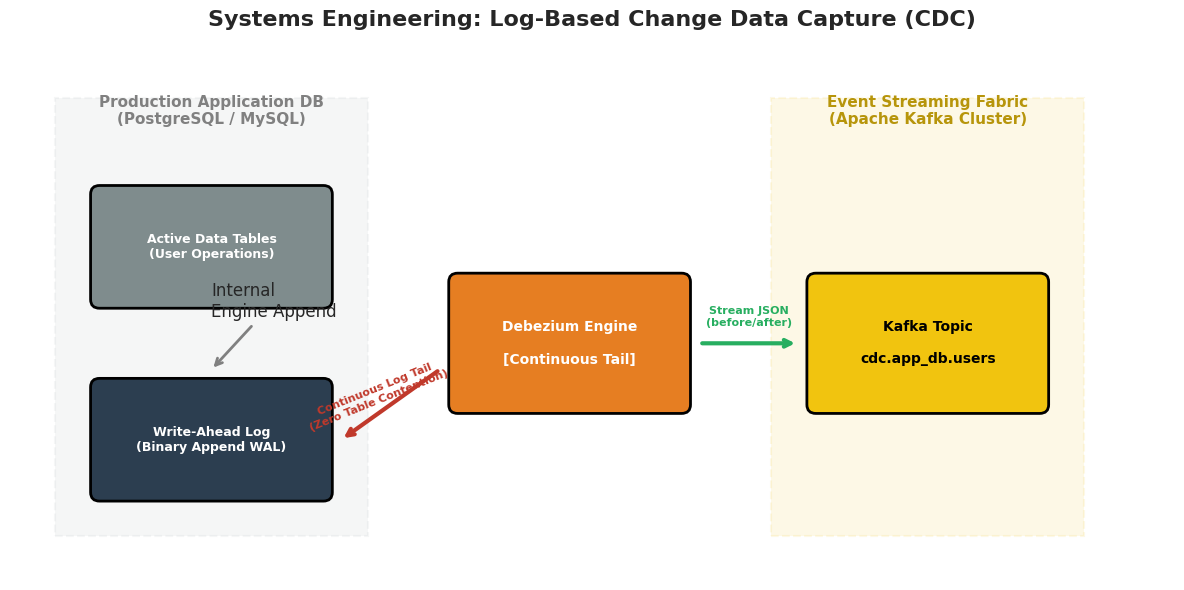

In [3]:
# Visualizing the CDC Debezium Infrastructure Topology
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Systems Engineering: Log-Based Change Data Capture (CDC)", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Systems Boundaries
# Production Database Box
db_box = patches.Rectangle((0.5, 0.5), 3.5, 5.0, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(db_box)
ax.text(2.25, 5.2, "Production Application DB\n(PostgreSQL / MySQL)", ha='center', color='gray', fontweight='bold', fontsize=11)

# Stream Transport Box
stream_box = patches.Rectangle((8.5, 0.5), 3.5, 5.0, fill=True, color='#f1c40f', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(stream_box)
ax.text(10.25, 5.2, "Event Streaming Fabric\n(Apache Kafka Cluster)", ha='center', color='#b7950b', fontweight='bold', fontsize=11)

# 2. Draw Components
# DB Active Tables
ax.add_patch(patches.FancyBboxPatch((1.0, 3.2), 2.5, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#7f8c8d'))
ax.text(2.25, 3.8, "Active Data Tables\n(User Operations)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Write-Ahead Log File (The Source of Truth)
ax.add_patch(patches.FancyBboxPatch((1.0, 1.0), 2.5, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#2c3e50'))
ax.text(2.25, 1.6, "Write-Ahead Log\n(Binary Append WAL)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Debezium Connector (The Bridge)
ax.add_patch(patches.FancyBboxPatch((5.0, 2.0), 2.5, 1.4, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#e67e22'))
ax.text(6.25, 2.7, "Debezium Engine\n\n[Continuous Tail]", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Kafka Target Topic
ax.add_patch(patches.FancyBboxPatch((9.0, 2.0), 2.5, 1.4, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f1c40f'))
ax.text(10.25, 2.7, "Kafka Topic\n\ncdc.app_db.users", ha='center', va='center', color='black', fontweight='bold', fontsize=10)


# 3. Draw Directed Edges (Data Paths)
# Table mutation writes to WAL natively
ax.annotate("Internal\nEngine Append", xy=(2.25, 2.4), xytext=(2.25, 3.0), arrowprops=dict(arrowstyle="->", lw=2, color="gray"))

# Debezium tails the WAL directly (No interaction with Tables!)
ax.annotate("", xy=(4.8, 2.4), xytext=(3.7, 1.6), arrowprops=dict(arrowstyle="<-", lw=3, color='#c0392b'))
ax.text(4.1, 1.7, "Continuous Log Tail\n(Zero Table Contention)", ha='center', fontweight='bold', color='#c0392b', fontsize=8, rotation=22)

# Debezium flushes structured messages to Kafka
ax.annotate("", xy=(8.8, 2.7), xytext=(7.7, 2.7), arrowprops=dict(arrowstyle="->", lw=3, color='#27ae60'))
ax.text(8.25, 2.9, "Stream JSON\n(before/after)", ha='center', fontweight='bold', color='#27ae60', fontsize=8)

plt.xlim(0, 13)
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Change Data Capture with Debezium like **A Financial Auditor Reading a Cashier's Receipt Roll vs. Interrupting the Cashier Directly**:

* **High-Water Marking (Interrupting the Cashier)**: Every 30 minutes, an internal data auditor physically runs up to the retail store register, forces the cashier to stop ringing up items, and demands: *"Filter through the computer and show me every sale since 2:00 PM."* This creates massive check-out delays for real customers standing in line. If an item was returned and erased from the system during that window, the auditor misses it entirely.
* **Log-Based CDC (Tapping the Receipt Roll)**: The auditor never talks to the cashier and never touches the checkout register computer. Instead, the auditor attaches a tiny splitter device directly to the receipt printer tape roll **(The Write-Ahead Log)**.
* As the cashier scans items, a carbon copy of every transaction, modification, and refund prints out onto the tape automatically. The auditor sits in a back room, reading the streaming data feed in real-time without causing a single millisecond of store delay.